# Clima provincial: NASA POWER

Extracción diaria para complementar las fuentes económicas de `fuentes_datos_externos_glamour.xlsx`. Se usa el mismo periodo, enero de 2016 a diciembre de 2025. NASA POWER aporta temperatura, precipitación, humedad y viento.

Las capitales provinciales aproximan la ubicación de las vendedoras. Se consulta una vez cada celda MERRA-2 de 0,5° de latitud por 0,625° de longitud y se reutiliza entre provincias. No es una medición puntual ni un promedio de toda la provincia. Las ubicaciones desconocidas quedan sin clima.

Fuentes: [NASA Daily API](https://power.larc.nasa.gov/docs/services/api/temporal/daily/), [metodología meteorológica](https://power.larc.nasa.gov/docs/methodology/meteorology/) y [catálogo geográfico de José M. Castañetto](https://github.com/jmcastagnetto/ubigeo-peru-aumentado).

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts/nasa_power.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.nasa_power import run, attach_climate
OUT = ROOT / 'data/external/nasa_power'
EJECUTAR_DESCARGA = False
INICIO, FIN = '2016-01-01', '2025-12-31'
REZAGO_MESES = 3

## Descargar o consultar

Activar `EJECUTAR_DESCARGA` para ejecutar el extractor. Reutiliza las respuestas guardadas y realiza como máximo dos consultas simultáneas. No requiere API key. Si cambia el periodo, el dataset, el catálogo, el código o el rezago, usar otro directorio `OUT`.

Los datos se guardan en CSV y Parquet. `raw/`, `manifest.json`, `protocol.json` y `diccionario.json` conservan respuestas, URLs, fechas de descarga, hashes y unidades.

In [2]:
if EJECUTAR_DESCARGA:
    run(output=OUT, start=INICIO, end=FIN, lag=REZAGO_MESES)
if not (OUT / 'resumen.json').exists():
    raise FileNotFoundError('Activar EJECUTAR_DESCARGA o ejecutar python -m scripts.nasa_power desde la raíz.')
resumen = json.loads((OUT / 'resumen.json').read_text())
protocolo = json.loads((OUT / 'protocol.json').read_text())
display(pd.Series({k: v for k, v in resumen.items() if not isinstance(v, (list, dict))}, name='valor').to_frame())
print('Periodo:', protocolo['start'], 'a', protocolo['end'])
print('Rezago del archivo guardado:', protocolo['lag_months_assumed'], 'meses')

,valor
provinces,148
grid_cells,107
daily_grid_rows,390871
monthly_province_rows,17760
model_rows,30821
model_rows_with_climate,30340
model_rows_missing_geography,481
incomplete_grid_months,0


Periodo: 2016-01-01 a 2025-12-31
Rezago del archivo guardado: 3 meses


## Cobertura geográfica y temporal

Se normalizan tildes, mayúsculas y espacios. La abreviatura local `Tumbes / contralmirante villa` se vincula explícitamente con `Contralmirante Villar`. No se asigna una capital departamental a una provincia desconocida. El catálogo geográfico es una compilación pública con fuentes INEI/RENIEC y otras; se conserva una copia y su hash.

In [3]:
cobertura = pd.read_csv(OUT / 'cobertura_ubicaciones.csv', dtype={'ubigeo_provincia': str})
mensual = pd.read_parquet(OUT / 'clima_mensual_provincias.parquet')
diario = pd.read_parquet(OUT / 'clima_diario_celdas.parquet')
display(cobertura[cobertura.grid_id.isna()][['departamento_key', 'provincia_key', 'filas_modelo']])
print(f"Cobertura para el modelo: {resumen['model_rows_with_climate'] / resumen['model_rows']:.2%}")
display(mensual.head())
display(diario.isna().sum().rename('valores_ausentes').to_frame())

,departamento_key,provincia_key,filas_modelo
0,__sin_dato__,__sin_dato__,30
6,amazonas,sin provincia,11
30,arequipa,sin provincia,70
37,ayacucho,sin provincia,7
51,cajamarca,sin provincia,8
53,callao,sin provincia,24
66,huancavelica,sin provincia,9
75,huanuco,sin provincia,14
82,ica,sin provincia,67
90,junin,sin provincia,4


Cobertura para el modelo: 98.44%


,departamento_key,provincia_key,ubigeo_provincia,capital,latitude,longitude,grid_latitude,grid_longitude,grid_id,mes_ref,...,temperatura_maxima_media_c,temperatura_minima_media_c,temperatura_maxima_c,temperatura_minima_c,humedad_relativa_pct,precipitacion_total_mm,precipitacion_maxima_diaria_mm,dias_lluvia_ge1mm,viento_m_s,mes_completo
0,la libertad,trujillo,130100,Trujillo,-8.1,-79.030556,-8.0,-78.75,-8.000_-78.750,2016-01-01,...,25.318387,14.597742,28.25,11.37,70.959355,34.67,5.81,9,2.458065,True
1,la libertad,trujillo,130100,Trujillo,-8.1,-79.030556,-8.0,-78.75,-8.000_-78.750,2016-02-01,...,25.857931,15.437241,28.21,13.55,76.190000,34.34,4.45,13,2.192414,True
2,la libertad,trujillo,130100,Trujillo,-8.1,-79.030556,-8.0,-78.75,-8.000_-78.750,2016-03-01,...,25.860000,15.365806,28.53,13.44,74.619032,36.15,9.64,10,2.028387,True
3,la libertad,trujillo,130100,Trujillo,-8.1,-79.030556,-8.0,-78.75,-8.000_-78.750,2016-04-01,...,25.567667,14.801000,27.85,13.20,70.233667,18.98,4.02,4,2.026667,True
4,la libertad,trujillo,130100,Trujillo,-8.1,-79.030556,-8.0,-78.75,-8.000_-78.750,2016-05-01,...,26.414516,14.591935,28.10,12.34,59.871613,2.83,1.30,1,1.953548,True


,valores_ausentes
grid_id,0
fecha,0
temperatura_media_c,0
temperatura_maxima_c,0
temperatura_minima_c,0
humedad_relativa_pct,0
precipitacion_mm,0
viento_m_s,0


## Variables mensuales

Temperaturas y humedad se promedian; también se conservan los extremos de temperatura. La precipitación diaria en mm/día se suma para obtener mm del mes. Se calculan el máximo diario de lluvia y el número de días con al menos 1 mm. El viento se promedia en m/s. Un resumen queda nulo si le falta algún día requerido, incluyendo meses parciales. Los días corresponden a tiempo solar local (LST), no al horario civil peruano.

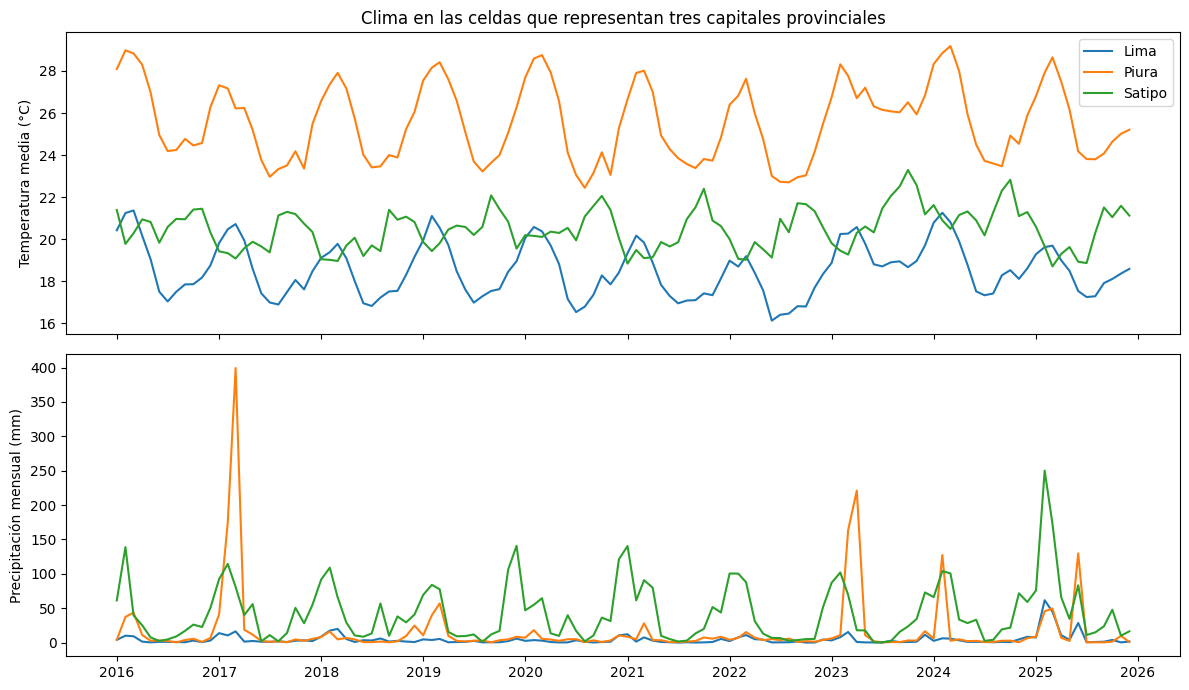

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for departamento, provincia in [('lima', 'lima'), ('piura', 'piura'), ('junin', 'satipo')]:
    d = mensual[(mensual.departamento_key == departamento) & (mensual.provincia_key == provincia)].sort_values('mes_ref')
    axes[0].plot(d.mes_ref, d.temperatura_media_c, label=provincia.title())
    axes[1].plot(d.mes_ref, d.precipitacion_total_mm, label=provincia.title())
axes[0].set_ylabel('Temperatura media (°C)')
axes[1].set_ylabel('Precipitación mensual (mm)')
axes[0].legend()
axes[0].set_title('Clima en las celdas que representan tres capitales provinciales')
plt.tight_layout()
plt.show()

## Cruce con el modelo

Se vincula por provincia, departamento y mes calendario exacto. Con rezago 3, abril de 2024 recibe el clima de enero de 2024. Se agregan diferencias de temperatura y lluvia frente al mismo mes del año anterior; cuando ese mes no está disponible quedan nulas. `nasa_mes_ref` es metadato, no predictor. `nasa_sin_dato` indica falta de alguna de las diez variables mensuales.

El rezago de tres meses es una hipótesis exploratoria, consistente con el análisis económico existente. NASA entrega historia revisada: esto no certifica la fecha de publicación original. La provincia de las vendedoras también es un snapshot cuya vigencia histórica debe verificarse.

Esta extracción prepara 13 variables candidatas; no demuestra que mejoren el modelo. La siguiente evaluación debe comparar base transaccional, base + clima y base + economía + clima con los mismos bloques temporales y parámetros fijos, aprendiendo cualquier imputación solamente en entrenamiento.

In [5]:
datos = pd.read_parquet(OUT / 'churn_con_clima.parquet')
variables = resumen['climate_features']
display(datos[['mes_obs', 'departamento', 'provincia', 'nasa_mes_ref', *variables]].head())
display(datos[variables].isna().mean().rename('fraccion_ausente').to_frame())
assert (datos.nasa_mes_ref < pd.to_datetime(datos.mes_obs)).all()
assert len(datos) == resumen['model_rows']
# Para explorar otro rezago sin descargar otra vez:
# originales = pd.read_csv(ROOT / 'data/processed/churn_dataset.csv')
# otro_rezago = attach_climate(originales, mensual, lag=2)

,mes_obs,departamento,provincia,nasa_mes_ref,nasa_temperatura_media_c,nasa_temperatura_maxima_media_c,nasa_temperatura_minima_media_c,nasa_temperatura_maxima_c,nasa_temperatura_minima_c,nasa_humedad_relativa_pct,nasa_precipitacion_total_mm,nasa_precipitacion_maxima_diaria_mm,nasa_dias_lluvia_ge1mm,nasa_viento_m_s,nasa_temperatura_delta12_c,nasa_precipitacion_delta12_mm,nasa_sin_dato
0,2025-07-01,la libertad,trujillo,2025-04-01,18.095333,23.890667,14.565333,26.81,12.31,76.217667,27.63,3.43,12.0,1.951333,-0.591000,7.22,0
1,2017-01-01,amazonas,utcubamba,2016-10-01,22.343548,29.929032,16.563871,33.39,14.12,59.690645,29.66,4.90,8.0,2.012581,NaN,NaN,0
2,2017-02-01,amazonas,utcubamba,2016-11-01,22.680667,30.967000,16.239667,33.83,10.76,52.302000,9.14,2.82,4.0,2.005667,NaN,NaN,0
3,2017-04-01,amazonas,utcubamba,2017-01-01,20.670645,27.186452,16.017419,29.98,14.65,68.620645,49.34,5.95,15.0,1.895806,-2.366129,6.46,0
4,2017-05-01,amazonas,utcubamba,2017-02-01,20.926071,27.351071,16.339286,30.77,15.08,66.405000,53.88,6.63,17.0,1.667857,-1.571170,17.11,0


,fraccion_ausente
nasa_temperatura_media_c,0.015606
nasa_temperatura_maxima_media_c,0.015606
nasa_temperatura_minima_media_c,0.015606
nasa_temperatura_maxima_c,0.015606
nasa_temperatura_minima_c,0.015606
nasa_humedad_relativa_pct,0.015606
nasa_precipitacion_total_mm,0.015606
nasa_precipitacion_maxima_diaria_mm,0.015606
nasa_dias_lluvia_ge1mm,0.015606
nasa_viento_m_s,0.015606
